In [15]:
## Imports and Initialization -------------------------------------------------|
print("Importing dependencies... ")

import sys, time
import os, os.path
sys.path.insert(0, "..")

# third party
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

# internal
import abstraction
import algorithm
from astropy.io import fits
from utility import IndexSchema, get_fits_paths, load_image_data
from examples.fits_to_mp4 import fits_to_mp4, data_to_mp4
from reference_method import ExternalRefs, RollingWindow

## Fetch Data ------------------------------------------------------------------

files_dir = os.path.abspath(os.path.join(".", "media"))
files = get_fits_paths(files_dir)
files = files[1:3]
# print("\n".join(files))
print(f"{len(files)} files found")

# create variable paths for destretching files
kernel_sizes: np.ndarray[np.int64] = np.array([64, 32])
out_off_dir = os.path.join(files_dir, "off")
out_off_dir_ccfilt = os.path.join(out_off_dir, "ccfilt")

Importing dependencies... 
2 files found


# Calculate offsets between two images

In [16]:
start = time.time()

# calculate offset vectors
algorithm.USE_CC_FILTERING = False
abstraction.calc_offset_vectors(
	files,
	out_off_dir,
	"off",
	kernel_sizes=kernel_sizes,
)

correlations = algorithm.SUBFIELD_CORRS

algorithm.USE_CC_FILTERING = True
abstraction.calc_offset_vectors(
	files,
	out_off_dir_ccfilt,
	"off",
	kernel_sizes=kernel_sizes,
)

elapsed = time.time() - start
print(f"elapsed time: {elapsed}")

Searching for image data in specified files...
processing image #0../home/tteck/Documents/Development/flct_destretch/flctdestretch/examples/media/test_1k_00.fits
processing image #1../home/tteck/Documents/Development/flct_destretch/flctdestretch/examples/media/test_1k_01.fits
Searching for image data in specified files...
processing image #0../home/tteck/Documents/Development/flct_destretch/flctdestretch/examples/media/test_1k_00.fits
processing image #1../home/tteck/Documents/Development/flct_destretch/flctdestretch/examples/media/test_1k_01.fits
elapsed time: 13.05449104309082


# Visualize artifacts by plotting log-scale values (very dark and light spots are artifacts)

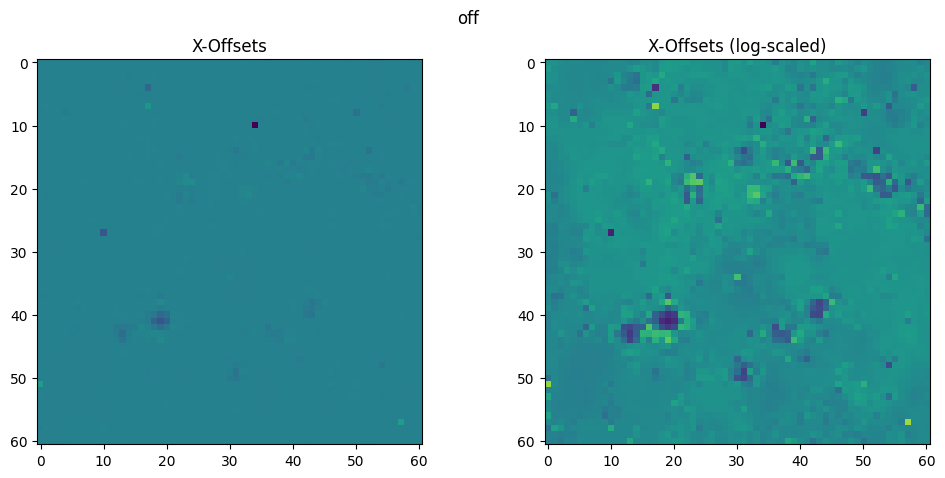

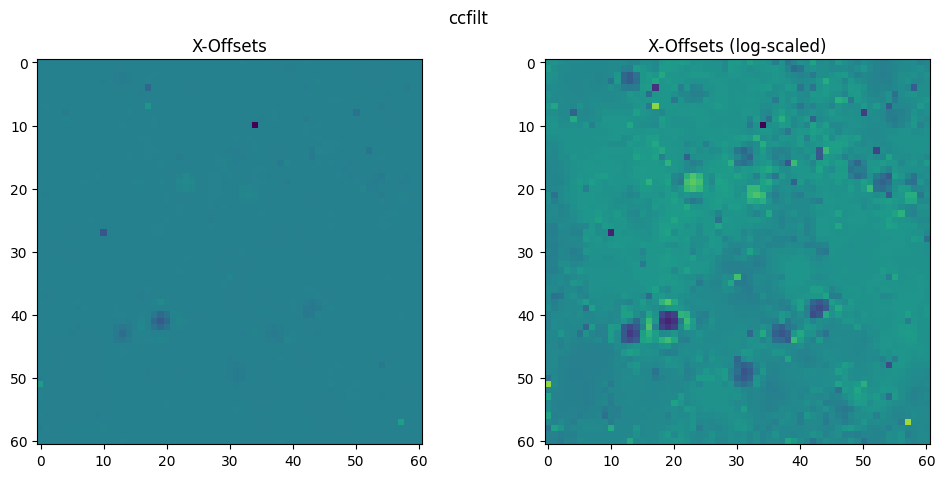

In [17]:
dirs = [out_off_dir, out_off_dir_ccfilt]
axis_index = 1

for dir in dirs:
    # load offset data
    off_files = get_fits_paths(dir)
    off_data = load_image_data(off_files[-1], None, None)

    # log-scale the offsets so smaller structures are visible
    off_data_logscl = off_data.copy()
    off_data_logscl -= np.median(off_data_logscl)
    off_data_logscl = np.sign(off_data_logscl) * np.log1p(np.abs(off_data_logscl))
    
    # normalize logscaled offs
    off_min_logscl = off_data_logscl.min()
    off_range_logscl = max(0.1, off_data_logscl.max() - off_min_logscl)
    off_data_logscl = (off_data_logscl - off_min_logscl) / off_range_logscl
    
    # normalize offs
    off_min = off_data.min()
    off_range = max(off_data.max() - off_min, 0.1)
    off_data = (off_data - off_min) / off_range
    
    # plot the images
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.imshow(off_data[axis_index, :, :], vmin=0, vmax=1)
    plt.title(f"{"YX"[axis_index]}-Offsets")
    
    plt.subplot(1,2,2)
    plt.imshow(off_data_logscl[axis_index, :, :], vmin=0, vmax=1)
    plt.title(f"{"YX"[axis_index]}-Offsets (log-scaled)")
    
    plt.suptitle(dir.split('/')[-1])
    plt.show()

#plt.figure(figsize=(50, 50))
#plt.imshow(correlations[axis_index])
#plt.colorbar()
